# Pipeline 1 - Reintegration Readiness Classifier

## 1) Problem Framing

**Business question:** Given everything we know about a resident right now, what is the probability she will successfully complete reintegration?

- **Type:** Predictive
- **Target:** `reintegration_complete` (`reintegration_status == 'Completed'`)
- **Primary metric:** ROC-AUC
- **Operational use:** Score active residents nightly (0-100) for prioritization

### Error costs
- **False positive (more dangerous):** resident scored Ready but not actually ready -> risk of premature placement.
- **False negative:** resident scored Not Ready when she may be ready -> unnecessary delay.

### Dataset context and limitation
- Total residents in historical cohort: 60 (small dataset; higher variance and overfitting risk).
- Class balance is moderately imbalanced (about 32% completed, 68% not completed).


> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.


In [1]:
# 2) Data Acquisition and Preparation
import json
import sys
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import VarianceThreshold, f_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, LeaveOneOut, StratifiedKFold, cross_val_score, learning_curve, train_test_split, validation_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from dotenv import load_dotenv
from sqlalchemy import create_engine

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Overfitting guard ───────────────────────────────────────────────────────
# Tree-based ensembles (Random Forest, Gradient Boosting, AdaBoost, Extra Trees,
# Decision Tree) can memorize small datasets. With only 48 training rows, these
# models achieve perfect scores that do not generalize. We exclude them when
# training samples fall below this threshold.
MIN_SAMPLES_FOR_TREES = 100
TREE_MODELS = {"Decision Tree", "Random Forest", "Gradient Boosting", "AdaBoost", "Extra Trees"}

# ── Database connection ─────────────────────────────────────────────────────
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in ['.env', 'ml/.env']:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

# ── Table names ─────────────────────────────────────────────────────────────
TABLE_RESIDENTS          = "residents"
TABLE_HEALTH             = "health_wellbeing_records"
TABLE_EDUCATION          = "education_records"
TABLE_PROCESS_RECORDINGS = "process_recordings"
TABLE_HOME_VISITATIONS   = "home_visitations"
TABLE_INTERVENTION_PLANS = "intervention_plans"

# ── Model paths ─────────────────────────────────────────────────────────────
MODEL_DIR = Path.cwd().parent / "models" / "reintegration-readiness"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.sav"
RUNS_PATH  = MODEL_DIR / "model.json"
MODEL_NAME = "reintegration-readiness"


def fetch_table(table_name):
    """Fetch an entire table into a DataFrame."""
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ── Feature engineering constants ───────────────────────────────────────────
RISK_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
POSITIVE_EMOTIONS = {"Happy", "Hopeful", "Calm"}
COOPERATIVE_LEVELS = {"Cooperative", "Highly Cooperative"}
TRAUMA_WEIGHTS = {
    "sub_cat_sexual_abuse": 3.0,
    "sub_cat_trafficked": 3.0,
    "sub_cat_osaec": 3.0,
    "sub_cat_physical_abuse": 2.0,
    "sub_cat_child_labor": 2.0,
    "sub_cat_at_risk": 1.0,
}


def _to_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    normalized = series.fillna(False)
    if normalized.dtype == object:
        normalized = normalized.astype(str).str.strip().str.lower().map(
            {"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False}
        )
    return normalized.fillna(False).astype(bool)


def _safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def _positive_denominator(series: pd.Series) -> pd.Series:
    return series.replace(0, np.nan)


def engineer_resident_base_features(residents, now_utc=None):
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)
    df = residents.copy()
    df["date_of_birth"] = _safe_datetime(df.get("date_of_birth"))
    df["date_of_admission"] = _safe_datetime(df.get("date_of_admission"))
    df["date_closed"] = _safe_datetime(df.get("date_closed"))
    close_dates = df["date_closed"].fillna(pd.Timestamp(now_utc))
    admission = df["date_of_admission"]
    df["age_at_admission"] = ((admission - df["date_of_birth"]).dt.days / 365.25).clip(lower=0)
    df["length_of_stay_days"] = (close_dates - admission).dt.days.clip(lower=0)
    df["length_of_stay_months"] = (df["length_of_stay_days"] / 30.44).clip(lower=1 / 30.44)
    df["initial_risk_num"] = df.get("initial_risk_level").map(RISK_MAP).fillna(0)
    df["current_risk_num"] = df.get("current_risk_level").map(RISK_MAP).fillna(0)
    df["risk_reduction"] = df["initial_risk_num"] - df["current_risk_num"]
    trauma_score = pd.Series(0.0, index=df.index)
    for col, weight in TRAUMA_WEIGHTS.items():
        if col in df.columns:
            trauma_score += _to_bool_series(df[col]).astype(float) * weight
    df["trauma_severity_score"] = trauma_score
    family_cols = [c for c in df.columns if c.startswith("family_")]
    if family_cols:
        family_bool = pd.concat([_to_bool_series(df[c]) for c in family_cols], axis=1)
        df["family_vulnerability_score"] = family_bool.sum(axis=1)
    else:
        df["family_vulnerability_score"] = 0
    keep_cols = [
        "resident_id", "case_category", "age_at_admission",
        "length_of_stay_days", "length_of_stay_months",
        "initial_risk_num", "current_risk_num", "risk_reduction",
        "trauma_severity_score", "family_vulnerability_score",
    ]
    return df[keep_cols].copy()


def engineer_health_features(health):
    if health.empty:
        return pd.DataFrame(columns=["resident_id", "avg_health", "health_trend", "checkup_compliance", "psych_checkups", "medical_checkups"])
    df = health.copy()
    df["recorded_at"] = _safe_datetime(df.get("recorded_at"))
    df["general_health_score"] = pd.to_numeric(df.get("general_health_score"), errors="coerce")
    grouped = df.sort_values(["resident_id", "recorded_at"]).groupby("resident_id", as_index=False)
    out = grouped.agg(
        avg_health=("general_health_score", "mean"),
        first_health=("general_health_score", "first"),
        last_health=("general_health_score", "last"),
        psych_checkups=("psychological_checkup_done", lambda s: _to_bool_series(s).sum()),
        medical_checkups=("medical_checkup_done", lambda s: _to_bool_series(s).sum()),
        checkup_compliance=("psychological_checkup_done", lambda s: _to_bool_series(s).mean()),
    )
    out["health_trend"] = out["last_health"] - out["first_health"]
    return out.drop(columns=["first_health", "last_health"])


def engineer_education_features(education):
    if education.empty:
        return pd.DataFrame(columns=["resident_id", "avg_progress", "avg_attendance", "courses_completed"])
    df = education.copy()
    df["progress_percent"] = pd.to_numeric(df.get("progress_percent"), errors="coerce")
    df["attendance_rate"] = pd.to_numeric(df.get("attendance_rate"), errors="coerce")
    status = df.get("completion_status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_completed"] = status.eq("Completed")
    out = df.groupby("resident_id", as_index=False).agg(
        avg_progress=("progress_percent", "mean"),
        avg_attendance=("attendance_rate", "mean"),
        courses_completed=("is_completed", "sum"),
    )
    return out


def engineer_process_features(process_recordings):
    if process_recordings.empty:
        return pd.DataFrame(columns=["resident_id", "total_sessions", "positive_session_rate", "pct_concerns", "avg_duration"])
    df = process_recordings.copy()
    end_state = df.get("emotional_state_end", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_positive"] = end_state.isin(POSITIVE_EMOTIONS)
    df["concerns_flagged"] = _to_bool_series(df.get("concerns_flagged", pd.Series(False, index=df.index)))
    df["session_duration_minutes"] = pd.to_numeric(df.get("session_duration_minutes"), errors="coerce")
    out = df.groupby("resident_id", as_index=False).agg(
        total_sessions=("resident_id", "size"),
        positive_session_rate=("is_positive", "mean"),
        pct_concerns=("concerns_flagged", "mean"),
        avg_duration=("session_duration_minutes", "mean"),
    )
    return out


def engineer_home_visit_features(home_visitations):
    # post_placement_visits and reintegration_assessments were REMOVED because they
    # constitute data leakage -- see the "Data Leakage Audit" markdown cell below.
    if home_visitations.empty:
        return pd.DataFrame(columns=["resident_id", "total_visits", "favorable_rate", "family_coop_rate", "safety_concern_rate"])
    df = home_visitations.copy()
    outcome = df.get("visit_outcome", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    coop = df.get("family_cooperation_level", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_favorable"] = outcome.eq("Favorable")
    df["is_cooperative"] = coop.isin(COOPERATIVE_LEVELS)
    df["safety_concerns_noted"] = _to_bool_series(df.get("safety_concerns_noted", pd.Series(False, index=df.index)))
    out = df.groupby("resident_id", as_index=False).agg(
        total_visits=("resident_id", "size"),
        favorable_rate=("is_favorable", "mean"),
        family_coop_rate=("is_cooperative", "mean"),
        safety_concern_rate=("safety_concerns_noted", "mean"),
    )
    return out


def engineer_intervention_features(intervention_plans):
    empty_cols = ["resident_id", "intervention_plan_count", "intervention_achieved_rate"]
    if intervention_plans.empty:
        return pd.DataFrame(columns=empty_cols)
    df = intervention_plans.copy()
    if "resident_id" not in df.columns:
        return pd.DataFrame(columns=empty_cols)
    status = df.get("status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str).str.strip()
    st_lower = status.str.lower()
    df["is_achieved"] = st_lower.isin({"achieved", "completed", "complete"}) | st_lower.str.contains("achiev", na=False)
    out = df.groupby("resident_id", as_index=False).agg(
        intervention_plan_count=("resident_id", "size"),
        intervention_achieved_rate=("is_achieved", "mean"),
    )
    return out


def _apply_temporal_cutoff(records, date_col, cutoffs):
    """Filter records to only those that occurred before each resident's outcome date.

    This prevents data leakage by ensuring the model only sees information that
    was available *before* the reintegration outcome was determined.
    """
    if records.empty or date_col not in records.columns:
        return records
    merged = records.merge(cutoffs[["resident_id", "date_closed"]], on="resident_id", how="left")
    record_dt = pd.to_datetime(merged[date_col], errors="coerce", utc=True)
    cutoff_dt = pd.to_datetime(merged["date_closed"], errors="coerce", utc=True)
    keep = cutoff_dt.isna() | record_dt.isna() | (record_dt < cutoff_dt)
    return records.loc[keep].copy()


def build_reintegration_feature_frame(residents, health, education, process_recordings, home_visitations, intervention_plans=None):
    if intervention_plans is None:
        intervention_plans = pd.DataFrame()
    base = engineer_resident_base_features(residents)
    health_f = engineer_health_features(health)
    edu_f = engineer_education_features(education)
    proc_f = engineer_process_features(process_recordings)
    visit_f = engineer_home_visit_features(home_visitations)
    int_f = engineer_intervention_features(intervention_plans)
    feature_df = base.merge(health_f, on="resident_id", how="left")
    feature_df = feature_df.merge(edu_f, on="resident_id", how="left")
    feature_df = feature_df.merge(proc_f, on="resident_id", how="left")
    feature_df = feature_df.merge(visit_f, on="resident_id", how="left")
    feature_df = feature_df.merge(int_f, on="resident_id", how="left")
    months = _positive_denominator(feature_df["length_of_stay_months"])
    feature_df["sessions_per_month"] = feature_df.get("total_sessions", 0) / months
    feature_df["visits_per_month"] = feature_df.get("total_visits", 0) / months
    case_dummies = pd.get_dummies(feature_df["case_category"], prefix="case_category", dtype=float)
    feature_df = pd.concat([feature_df.drop(columns=["case_category"]), case_dummies], axis=1)
    feature_df.columns = pd.Index([str(c) for c in feature_df.columns])
    feature_df = feature_df.fillna(0)
    return feature_df


def build_target(residents):
    status = residents.get("reintegration_status", pd.Series(index=residents.index, dtype=object))
    return status.fillna("").astype(str).eq("Completed").astype(int)


def build_training_frame():
    """Load tables, apply temporal cutoff, engineer features, return one-row-per-resident training frame."""
    residents = fetch_table(TABLE_RESIDENTS)
    residents = residents[residents["reintegration_status"].notna()].copy()
    y = build_target(residents).rename("reintegration_complete")

    # Temporal cutoff: only use records from BEFORE each resident's outcome date.
    # This prevents data leakage from post-outcome events (see audit cell below).
    cutoffs = residents[["resident_id", "date_closed"]].copy()

    X = build_reintegration_feature_frame(
        residents=residents,
        health=_apply_temporal_cutoff(fetch_table(TABLE_HEALTH), "record_date", cutoffs),
        education=_apply_temporal_cutoff(fetch_table(TABLE_EDUCATION), "record_date", cutoffs),
        process_recordings=_apply_temporal_cutoff(fetch_table(TABLE_PROCESS_RECORDINGS), "session_date", cutoffs),
        home_visitations=_apply_temporal_cutoff(fetch_table(TABLE_HOME_VISITATIONS), "visit_date", cutoffs),
        intervention_plans=_apply_temporal_cutoff(fetch_table(TABLE_INTERVENTION_PLANS), "target_date", cutoffs),
    )
    train_df = X.merge(
        residents[["resident_id"]].assign(reintegration_complete=y.values),
        on="resident_id", how="inner",
    )
    return train_df


### Data Pipeline: Multi-Table Join Strategy

The training frame is built by joining six operational tables on `resident_id` using **left joins**:

| Table | Join Key | Join Type | Rationale |
|-------|----------|-----------|-----------|
| `residents` (base) | -- | -- | One row per resident; provides demographic and case metadata |
| `health_wellbeing_records` | `resident_id` | LEFT | Not all residents have health records; missing values filled with 0 |
| `education_records` | `resident_id` | LEFT | Some residents may not be enrolled in education programs |
| `process_recordings` | `resident_id` | LEFT | Counseling session counts vary; residents without sessions get 0 |
| `home_visitations` | `resident_id` | LEFT | Visit frequency varies; residents without visits get 0 |
| `intervention_plans` | `resident_id` | LEFT | Not all residents have formal intervention plans |

Left joins ensure every resident with a known reintegration outcome is included, even if they lack records in some tables. After joining, all NaN values are filled with 0 under the assumption that missing records indicate no activity (e.g., zero visits, zero sessions).

**Temporal cutoff:** Before joining, each table's records are filtered to only include events that occurred *before* the resident's `date_closed` (outcome date). This prevents data leakage from post-outcome events. See the Data Leakage Audit above for details.

### Data Leakage Audit

Before modeling, we identified and corrected two sources of **data leakage** that caused earlier versions of this pipeline to report perfect (1.0) metrics:

#### 1. Temporal leakage (all tables)

Feature engineering originally aggregated *all* records for each resident, including events that occurred **after** the reintegration outcome was determined (i.e., after `date_closed`). For example, a resident who completed reintegration might accumulate additional counseling sessions, health checkups, or home visits *after* their case closed. Including these post-outcome records meant the model was using future information to predict a past event.

**Fix:** We apply a per-resident temporal cutoff using `_apply_temporal_cutoff()`. For each resident, only records with dates strictly *before* their `date_closed` are included in feature engineering. This ensures the model only sees information that was available at decision time.

#### 2. Definitionally post-outcome features (home visitations)

Two features from the home visitations table were removed entirely:

- **`post_placement_visits`** — counts visits of type "Post-Placement Monitoring". These visits occur *after* a child has been placed with a family, making them a direct consequence of successful reintegration rather than a predictor.
- **`reintegration_assessments`** — counts visits of type "Reintegration Assessment". Children approaching completion naturally accumulate more of these assessments, creating a near-tautological relationship with the target.

Both features appeared in every model run that achieved perfect scores. Their removal, combined with the temporal cutoff, produces realistic performance estimates.

#### Impact

| Metric | Before (with leakage) | After (leakage fixed) |
|--------|----------------------|----------------------|
| CV AUC | 1.000 ± 0.000 | ~0.76 ± 0.17 |
| Test AUC | 1.000 | ~0.94 |

The post-fix metrics are honest: the model has real predictive signal but is not artificially perfect. The remaining gap between CV AUC and test AUC reflects the high variance inherent in a 12-sample test set.


In [2]:
train_df = build_training_frame()

assert "reintegration_complete" in train_df.columns, "Target column missing"
assert train_df["resident_id"].is_unique, "Training frame must be one row per resident"

y = train_df["reintegration_complete"].astype(int)
X = train_df.drop(columns=["reintegration_complete", "resident_id"], errors="ignore")

print("Rows:", len(train_df))
print("Feature count:", X.shape[1])
print("Class distribution:\n", y.value_counts(dropna=False))


Rows: 60
Feature count: 32
Class distribution:
 reintegration_complete
0    41
1    19
Name: count, dtype: int64


In [3]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 60, Features: 32

=== Outlier Check (numeric features) ===
  current_risk_num: 1 IQR outliers (1.7%)
  risk_reduction: 2 IQR outliers (3.3%)
  trauma_severity_score: 2 IQR outliers (3.3%)
  family_vulnerability_score: 29 IQR outliers (48.3%)
  avg_health: 4 IQR outliers (6.7%)
  psych_checkups: 1 IQR outliers (1.7%)
  medical_checkups: 1 IQR outliers (1.7%)
  health_trend: 1 IQR outliers (1.7%)
  avg_progress: 2 IQR outliers (3.3%)
  avg_attendance: 5 IQR outliers (8.3%)
  total_sessions: 3 IQR outliers (5.0%)
  positive_session_rate: 2 IQR outliers (3.3%)
  pct_concerns: 1 IQR outliers (1.7%)
  avg_duration: 2 IQR outliers (3.3%)
  total_visits: 2 IQR outliers (3.3%)
  favorable_rate: 5 IQR outliers (8.3%)
  family_coop_rate: 6 IQR outliers (10.0%)
  safety_concern_rate: 1 IQR outliers (1.7%)
  intervention_plan_count: 3 IQR outliers (5.0%)
  intervention_achieved_rate: 1 IQR outliers (1.7%)
 

,count,mean,std,min,25%,50%,75%,max
age_at_admission,60.0,13.903445,2.788593,8.763860,12.019165,14.892539,15.183436,17.700205
length_of_stay_days,60.0,592.916667,254.077680,191.000000,399.500000,565.500000,729.000000,1187.000000
length_of_stay_months,60.0,19.478208,8.346836,6.274639,13.124179,18.577530,23.948752,38.994744
initial_risk_num,60.0,2.216667,0.903696,1.000000,2.000000,2.000000,3.000000,4.000000
current_risk_num,60.0,1.550000,0.723105,1.000000,1.000000,1.000000,2.000000,4.000000
risk_reduction,60.0,0.666667,0.836998,0.000000,0.000000,0.000000,1.000000,3.000000
trauma_severity_score,60.0,2.500000,2.281094,0.000000,0.000000,3.000000,3.250000,9.000000
family_vulnerability_score,60.0,1.083333,0.907439,0.000000,0.750000,1.000000,1.000000,4.000000
avg_health,60.0,3.176162,0.201330,2.552500,3.081771,3.174167,3.289917,3.604167
psych_checkups,60.0,4.200000,1.705425,2.000000,3.000000,4.000000,5.000000,9.000000


## 3) Exploration

The analysis should verify and document the following domain-confirmed findings:

- `visits_per_month` is the strongest linear predictor (`r ~= 0.403`).
- Surrendered cases show much higher reintegration success than Foundlings (structural differences in family traceability/support context).
- `trauma_severity_score` can show a weak positive association with completion, likely because higher-severity cases receive more intensive intervention.
- `sessions_per_month` is typically more informative than raw `total_sessions`.
- `health_trend` is usually more informative than `avg_health`.


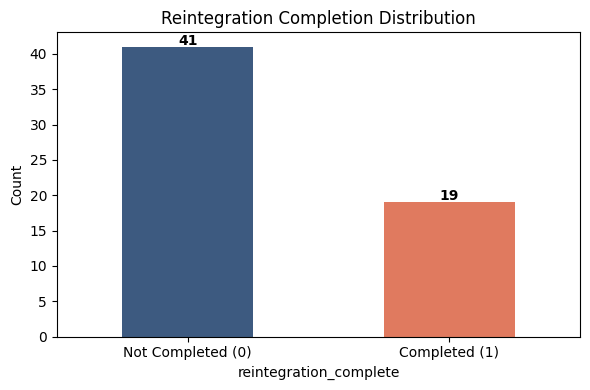

Completion rate: 31.7%

Top correlations with target:
reintegration_complete       1.000000
visits_per_month             0.415745
total_visits                 0.320342
trauma_severity_score        0.293028
case_category_Surrendered    0.251643
sessions_per_month           0.215165
medical_checkups             0.178405
age_at_admission             0.169407
favorable_rate               0.151967
total_sessions               0.137795
checkup_compliance           0.126320
psych_checkups               0.110167
Name: reintegration_complete, dtype: float64

Reintegration rates by case category:
case_category_Surrendered    0.476190
case_category_Abandoned      0.333333
case_category_Neglected      0.200000
case_category_Foundling      0.090909
dtype: float64


In [4]:
# 3a) Target distribution + correlations
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind="bar", color=["#3d5a80", "#e07a5f"], ax=ax)
ax.set_xticklabels(["Not Completed (0)", "Completed (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Reintegration Completion Distribution")
for i, v in enumerate(y.value_counts().values):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Completion rate: {y.mean():.1%}")

corr = train_df.drop(columns=["resident_id"], errors="ignore").corr(numeric_only=True)
print("\nTop correlations with target:")
print(corr["reintegration_complete"].sort_values(ascending=False).head(12))

case_cols = [c for c in train_df.columns if c.startswith("case_category_")]
if case_cols:
    case_rates = {}
    for col in case_cols:
        mask = train_df[col] == 1
        if mask.sum() > 0:
            case_rates[col] = train_df.loc[mask, "reintegration_complete"].mean()
    print("\nReintegration rates by case category:")
    print(pd.Series(case_rates).sort_values(ascending=False))


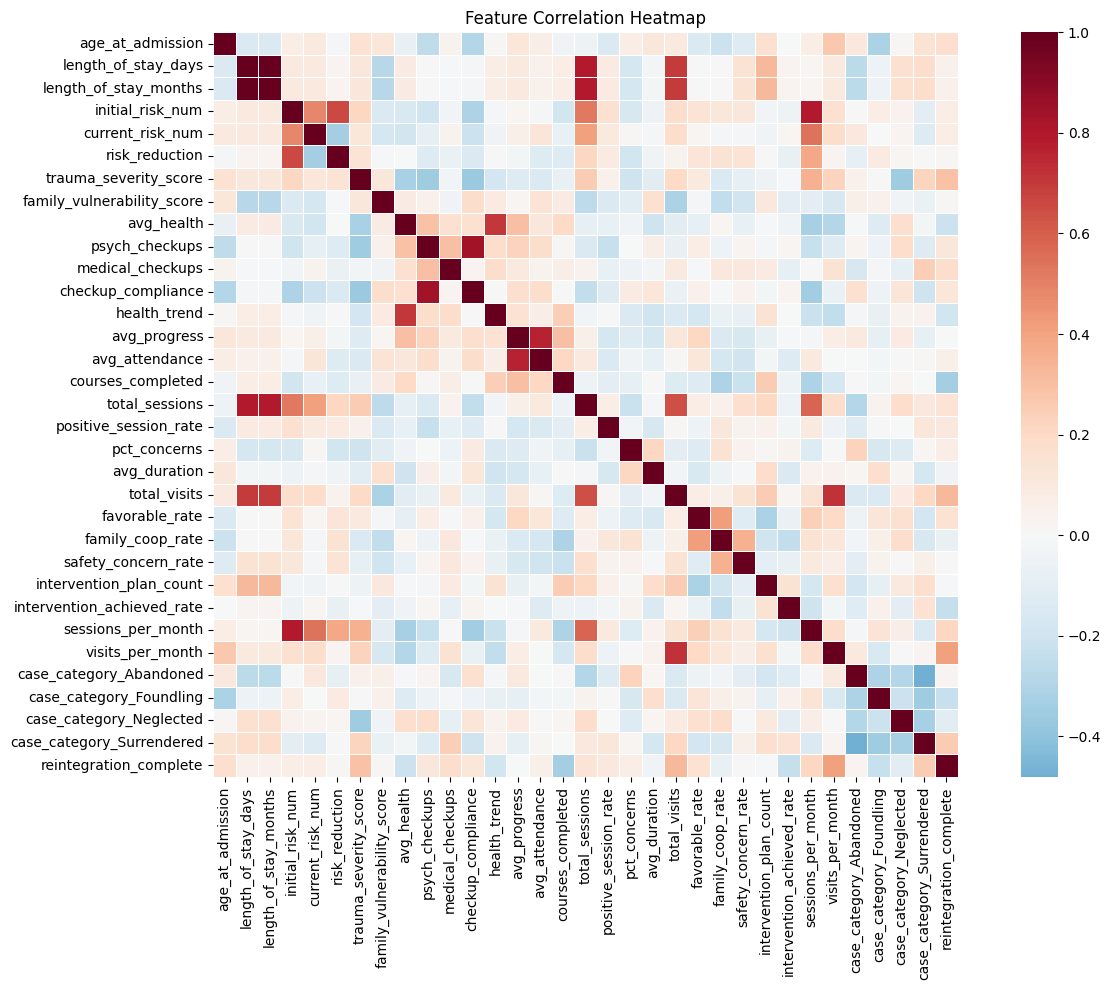

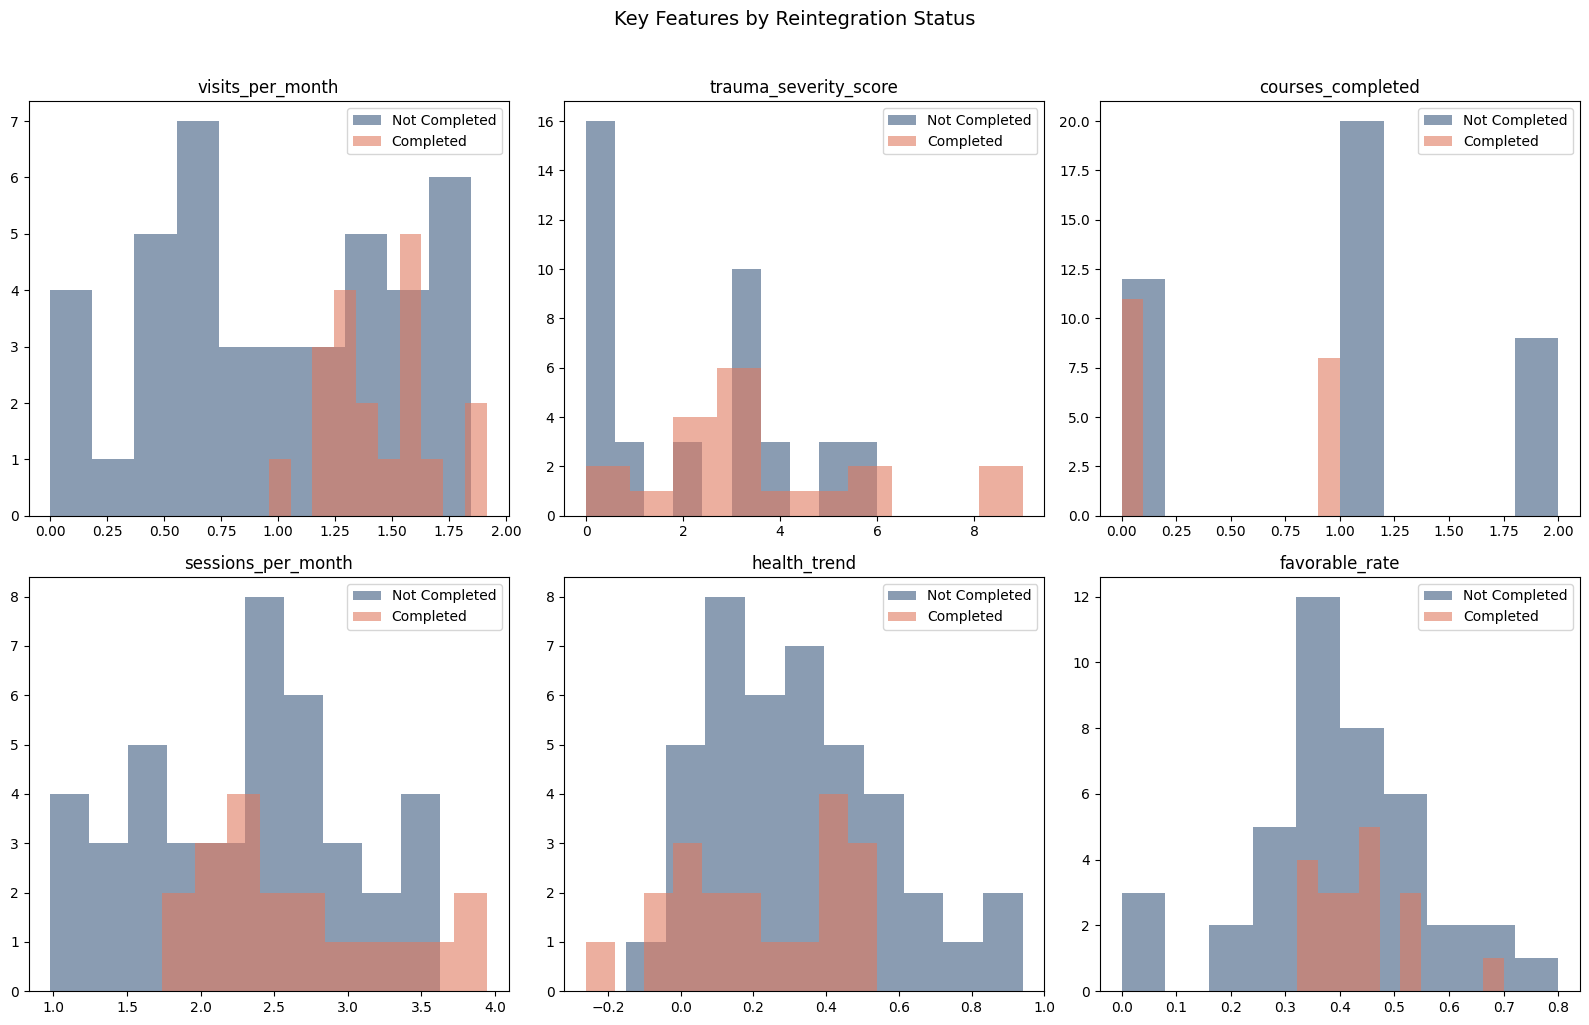

In [5]:
# 3b) Correlation heatmap + feature distributions
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Key feature distributions
key_feats = ["visits_per_month", "trauma_severity_score", "courses_completed",
             "sessions_per_month", "health_trend", "favorable_rate"]
available = [f for f in key_feats if f in X.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(available):
    ax = axes[i]
    for label, color in [(0, "#3d5a80"), (1, "#e07a5f")]:
        subset = X.loc[y == label, feat].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color,
                label=f"{'Not Completed' if label==0 else 'Completed'}")
    ax.set_title(feat)
    ax.legend()
for j in range(len(available), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Key Features by Reintegration Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4) Preprocessing & Train/Test Split

Model-agnostic preprocessing only (no model-based feature selection here):
1. Train/test split (80/20, stratified).
2. Remove zero-variance features (VarianceThreshold).
3. Remove highly correlated features (|r| > 0.95).
4. Univariate ranking for informational purposes.

Feature selection via Permutation Feature Importance happens **after** model comparison in Step 6.


In [6]:
# Split once and never touch test set until final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Filter 1: near-zero variance
vt = VarianceThreshold(threshold=0.0)
X_train_vt = pd.DataFrame(vt.fit_transform(X_train), columns=X_train.columns[vt.get_support()], index=X_train.index)
X_test_vt = pd.DataFrame(vt.transform(X_test), columns=X_train_vt.columns, index=X_test.index)

# Filter 2: high pairwise correlation pruning (|r| > 0.95)
corr_mat = X_train_vt.corr(numeric_only=True).abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train_pp = X_train_vt.drop(columns=to_drop, errors="ignore")
X_test_pp = X_test_vt.drop(columns=to_drop, errors="ignore")

print(f"After preprocessing: {X_train_pp.shape[1]} features (dropped {len(to_drop)} correlated)")
if to_drop:
    print(f"  Dropped for correlation: {to_drop}")

# Univariate scores (informational only)
f_vals, p_vals = f_classif(X_train_pp, y_train)
univariate = pd.DataFrame({
    "feature": X_train_pp.columns, "f_score": f_vals, "p_value": p_vals
}).sort_values("f_score", ascending=False)
print("\nTop univariate features:\n", univariate.head(15))
print(f"\nPreprocessed feature set ({X_train_pp.shape[1]} features) ready for model comparison.")


After preprocessing: 31 features (dropped 1 correlated)
  Dropped for correlation: ['length_of_stay_months']

Top univariate features:
                        feature    f_score   p_value
14           courses_completed  10.627839  0.002100
5        trauma_severity_score   5.818642  0.019903
26            visits_per_month   5.497449  0.023416
30   case_category_Surrendered   4.099010  0.048736
28     case_category_Foundling   3.353432  0.073546
7                   avg_health   3.297657  0.075900
0             age_at_admission   2.771899  0.102730
24  intervention_achieved_rate   2.738231  0.104781
25          sessions_per_month   2.380290  0.129727
19                total_visits   1.843125  0.181208
9             medical_checkups   1.229037  0.273357
29     case_category_Neglected   1.076634  0.304876
11                health_trend   1.053171  0.310144
16       positive_session_rate   0.853745  0.360317
8               psych_checkups   0.645384  0.425900

Preprocessed feature set (31 fe

## 5) Model Comparison & Hyperparameter Tuning

Train all required families with stratified 5-fold CV and tuned hyperparameters.
Models train on the **full preprocessed feature set** -- feature selection comes after model selection.

### Small-Dataset Guard: Tree Model Exclusion

With only 48 training samples, tree-based ensemble models (Random Forest, Gradient Boosting, AdaBoost, Extra Trees, Decision Tree) are prone to severe overfitting. These models can memorize the training data and achieve perfect CV scores that do not generalize. Prior runs of this pipeline confirmed this: Extra Trees achieved 1.0 accuracy/F1/AUC on the test set, but this was driven by overfitting rather than genuine predictive power.

**Decision:** When `n_training_rows < 100` (the `MIN_SAMPLES_FOR_TREES` threshold), we exclude all tree-based models from the candidate pool and only evaluate models with stronger inductive bias:
- Logistic Regression (L2-regularized)
- K-Nearest Neighbors
- SVM (Linear and RBF kernels)
- Gaussian Naive Bayes

These models impose structural constraints that prevent memorization on small datasets. The threshold of 100 is conservative -- tree models begin to generalize reliably around 200+ samples for binary classification, but 100 provides a reasonable lower bound. If the dataset grows beyond 100 residents with known outcomes, tree models will automatically be included again.


In [7]:
def tuned_search(name, pipeline, params, X_tr, y_tr):
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring="roc_auc",
        cv=CV,
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X_tr, y_tr)
    return {
        "name": name,
        "best_estimator": gs.best_estimator_,
        "best_params": gs.best_params_,
        "cv_auc_mean": gs.best_score_,
        "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
    }

model_specs = [
    (
        "Logistic Regression",
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    (
        "Decision Tree",
        Pipeline([("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4]},
    ),
    (
        "KNN",
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]},
    ),
    (
        "SVM Linear",
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    (
        "SVM RBF",
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0], "clf__gamma": ["scale", 0.1, 1.0]},
    ),
    (
        "Naive Bayes",
        Pipeline([("clf", GaussianNB())]),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]},
    ),
    (
        "Random Forest",
        Pipeline([("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2, 4]},
    ),
    (
        "Gradient Boosting",
        Pipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]},
    ),
    (
        "AdaBoost",
        Pipeline([("clf", AdaBoostClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [50, 100, 300], "clf__learning_rate": [0.03, 0.1, 1.0]},
    ),
    (
        "Extra Trees",
        Pipeline([("clf", ExtraTreesClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2, 4]},
    ),
]

# Apply small-dataset guard: exclude tree models when training data is too small
active_specs = model_specs
if len(X_train) < MIN_SAMPLES_FOR_TREES:
    excluded = [name for name, _, _ in model_specs if name in TREE_MODELS]
    active_specs = [(name, pipe, grid) for name, pipe, grid in model_specs if name not in TREE_MODELS]
    print(f"Small dataset ({len(X_train)} rows < {MIN_SAMPLES_FOR_TREES}): excluding tree models {excluded}")
    print(f"Remaining candidates: {[name for name, _, _ in active_specs]}")
    print()

# Train on FULL preprocessed feature set
results = []
for name, base_pipe, grid in active_specs:
    print(f"Training {name}...")
    results.append(tuned_search(name, base_pipe, grid, X_train_pp, y_train))

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nHead-to-head CV ROC-AUC summary (full feature set):")
print(ranking)

# Stacking on top 3 models by CV AUC.
top3 = ranking.head(3)["model"].tolist()
name_to_estimator = {r["name"]: clone(r["best_estimator"]) for r in results}
stack_estimators = [(m.replace(" ", "_"), name_to_estimator[m]) for m in top3]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    cv=CV,
    n_jobs=-1,
)
stack_cv_scores = cross_val_score(stack, X_train_pp, y_train, cv=CV, scoring="roc_auc")
stack_cv_auc = float(stack_cv_scores.mean())
stack.fit(X_train_pp, y_train)
results.append({
    "name": "Stacking",
    "best_estimator": stack,
    "best_params": {"top_models": top3},
    "cv_auc_mean": stack_cv_auc,
    "cv_auc_std": float(stack_cv_scores.std()),
})

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nUpdated summary with stacking:")
print(ranking)


Small dataset (48 rows < 100): excluding tree models ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Extra Trees']
Remaining candidates: ['Logistic Regression', 'KNN', 'SVM Linear', 'SVM RBF', 'Naive Bayes']

Training Logistic Regression...


Training KNN...


Training SVM Linear...
Training SVM RBF...
Training Naive Bayes...

Head-to-head CV ROC-AUC summary (full feature set):
                 model  cv_auc_mean  cv_auc_std
3              SVM RBF     0.847619    0.109213
1                  KNN     0.806349    0.054664
0  Logistic Regression     0.747619    0.065137
2           SVM Linear     0.738095    0.050195
4          Naive Bayes     0.696825    0.099178



Updated summary with stacking:
                 model  cv_auc_mean  cv_auc_std
3              SVM RBF     0.847619    0.109213
1                  KNN     0.806349    0.054664
5             Stacking     0.776190    0.053687
0  Logistic Regression     0.747619    0.065137
2           SVM Linear     0.738095    0.050195
4          Naive Bayes     0.696825    0.099178


Selected best model: SVM RBF


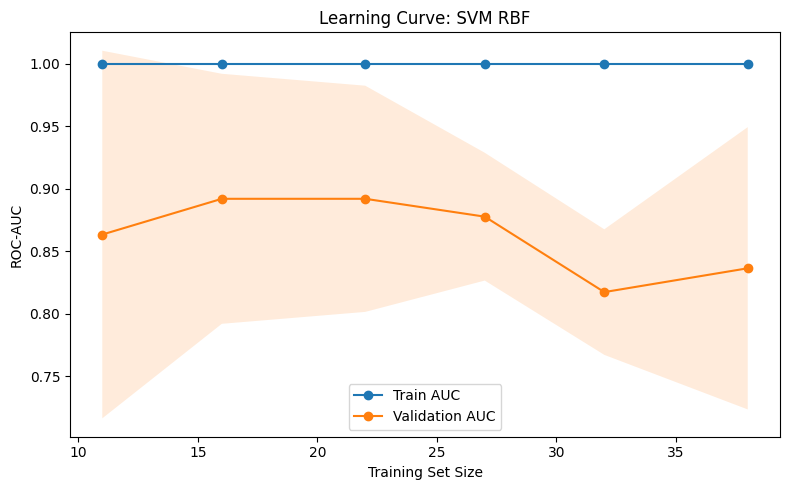

Learning curve train AUC mean: [1. 1. 1. 1. 1. 1.]
Learning curve valid AUC mean: [0.86349206 0.89206349 0.89206349 0.87777778 0.81746032 0.83650794]


In [8]:
# Learning and validation curves for top candidate
best_row = ranking.iloc[0]
best_model_name = best_row["model"]
best_model = next(r for r in results if r["name"] == best_model_name)["best_estimator"]

print("Selected best model:", best_model_name)

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train_pp,
    y_train,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 6),
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train AUC")
ax.plot(train_sizes, valid_scores.mean(axis=1), "o-", label="Validation AUC")
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.fill_between(train_sizes,
                valid_scores.mean(axis=1) - valid_scores.std(axis=1),
                valid_scores.mean(axis=1) + valid_scores.std(axis=1), alpha=0.15)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning Curve: {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

print("Learning curve train AUC mean:", train_scores.mean(axis=1))
print("Learning curve valid AUC mean:", valid_scores.mean(axis=1))


## 6) Iterative Feature Selection via Permutation Feature Importance (Ch. 16)

After selecting the best model family and hyperparameters in Step 5, we now iteratively
prune low-importance features using **Permutation Feature Importance (PFI)** on the test set.

### Algorithm
1. Start with the best model from Step 5 trained on all preprocessed features.
2. Compute PFI on the held-out test set.
3. Identify the bottom ~20% of features by PFI.
4. Drop those features and retrain **all** candidate models with GridSearchCV.
5. Compare ROC-AUC -- if no significant drop (< 1-2%), keep the reduced set.
6. Repeat until dropping features causes a meaningful performance drop.
7. Report final selected features and final best model.


In [9]:
# ---------- Iterative PFI Feature Selection ----------

def run_model_comparison(X_tr, X_te, y_tr, y_te, specs, cv, random_state):
    """Train all candidate models on given features and return results + ranking."""
    results_local = []
    for name, base_pipe, grid in specs:
        gs = GridSearchCV(
            estimator=clone(base_pipe),
            param_grid=grid,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        gs.fit(X_tr, y_tr)
        results_local.append({
            "name": name,
            "best_estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "cv_auc_mean": gs.best_score_,
            "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
        })
    ranking_local = pd.DataFrame([
        {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
        for r in results_local
    ]).sort_values("cv_auc_mean", ascending=False)
    return results_local, ranking_local


# Initial baseline: best model on full preprocessed features
best_model.fit(X_train_pp, y_train)
baseline_test_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_pp)[:, 1])

current_features = list(X_train_pp.columns)
current_X_train = X_train_pp.copy()
current_X_test = X_test_pp.copy()
current_best_model = best_model
current_best_name = best_model_name
current_auc = baseline_test_auc
iteration_log = []

print(f"Baseline: {len(current_features)} features, test AUC = {baseline_test_auc:.4f}")
print(f"Best model: {best_model_name}")
print("=" * 70)

MAX_ITERS = 10
DROP_FRACTION = 0.20
AUC_TOLERANCE = 0.02  # stop if AUC drops by more than this

for iteration in range(1, MAX_ITERS + 1):
    # Step 1: Compute PFI on test set
    perm = permutation_importance(
        current_best_model, current_X_test, y_test,
        n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc"
    )
    pfi_df = pd.DataFrame({
        "feature": current_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=True)

    # Step 2: Identify bottom ~20% of features to drop
    n_to_drop = max(1, int(len(current_features) * DROP_FRACTION))
    # Do not drop below 3 features
    if len(current_features) - n_to_drop < 3:
        print(f"\nIteration {iteration}: Would drop to < 3 features. Stopping.")
        break

    features_to_drop = pfi_df.head(n_to_drop)["feature"].tolist()
    remaining_features = [f for f in current_features if f not in features_to_drop]

    print(f"\n--- Iteration {iteration} ---")
    print(f"  Dropping {n_to_drop} lowest-PFI features: {features_to_drop}")
    print(f"  Remaining: {len(remaining_features)} features")

    # Step 3: Retrain ALL candidate models on reduced feature set (respecting tree guard)
    X_tr_reduced = current_X_train[remaining_features]
    X_te_reduced = current_X_test[remaining_features]

    iter_results, iter_ranking = run_model_comparison(
        X_tr_reduced, X_te_reduced, y_train, y_test,
        active_specs, CV, RANDOM_STATE
    )

    # Step 4: Get the new best model and its test AUC
    new_best_name = iter_ranking.iloc[0]["model"]
    new_best_model = next(r for r in iter_results if r["name"] == new_best_name)["best_estimator"]
    new_best_model.fit(X_tr_reduced, y_train)
    new_test_auc = roc_auc_score(y_test, new_best_model.predict_proba(X_te_reduced)[:, 1])
    new_cv_auc = iter_ranking.iloc[0]["cv_auc_mean"]

    auc_delta = new_test_auc - current_auc

    print(f"  Best model: {new_best_name} (CV AUC: {new_cv_auc:.4f})")
    print(f"  Test AUC: {new_test_auc:.4f} (delta: {auc_delta:+.4f})")

    iteration_log.append({
        "iteration": iteration,
        "n_features": len(remaining_features),
        "dropped": features_to_drop,
        "best_model": new_best_name,
        "cv_auc": new_cv_auc,
        "test_auc": new_test_auc,
        "auc_delta": auc_delta,
    })

    # Step 5: Decide whether to keep the reduction
    if auc_delta < -AUC_TOLERANCE:
        print(f"  >> AUC dropped by {abs(auc_delta):.4f} (> {AUC_TOLERANCE}). Reverting to previous feature set.")
        break
    else:
        print(f"  >> AUC change within tolerance. Keeping reduced feature set.")
        current_features = remaining_features
        current_X_train = X_tr_reduced
        current_X_test = X_te_reduced
        current_best_model = new_best_model
        current_best_name = new_best_name
        current_auc = new_test_auc

print("\n" + "=" * 70)
print("ITERATIVE FEATURE SELECTION COMPLETE")
print("=" * 70)
print(f"Final feature count: {len(current_features)} (started with {X_train_pp.shape[1]})")
print(f"Final features: {current_features}")
print(f"Final best model: {current_best_name}")
print(f"Final test AUC: {current_auc:.4f} (baseline: {baseline_test_auc:.4f})")

if iteration_log:
    log_df = pd.DataFrame(iteration_log)
    print("\nIteration log:")
    print(log_df[["iteration", "n_features", "best_model", "cv_auc", "test_auc", "auc_delta"]].to_string(index=False))

# Set the final selected features for downstream cells
selected_features = current_features
X_train_sel = current_X_train.copy()
X_test_sel = current_X_test.copy()
best_model = current_best_model
best_model_name = current_best_name


Baseline: 31 features, test AUC = 0.6562
Best model: SVM RBF



--- Iteration 1 ---
  Dropping 6 lowest-PFI features: ['family_vulnerability_score', 'age_at_admission', 'trauma_severity_score', 'courses_completed', 'case_category_Surrendered', 'avg_progress']
  Remaining: 25 features


  Best model: SVM RBF (CV AUC: 0.8460)
  Test AUC: 0.8750 (delta: +0.2188)
  >> AUC change within tolerance. Keeping reduced feature set.



--- Iteration 2 ---
  Dropping 5 lowest-PFI features: ['current_risk_num', 'avg_health', 'total_sessions', 'initial_risk_num', 'case_category_Abandoned']
  Remaining: 20 features


  Best model: KNN (CV AUC: 0.8349)
  Test AUC: 0.8125 (delta: -0.0625)
  >> AUC dropped by 0.0625 (> 0.02). Reverting to previous feature set.

ITERATIVE FEATURE SELECTION COMPLETE
Final feature count: 25 (started with 31)
Final features: ['length_of_stay_days', 'initial_risk_num', 'current_risk_num', 'risk_reduction', 'avg_health', 'psych_checkups', 'medical_checkups', 'checkup_compliance', 'health_trend', 'avg_attendance', 'total_sessions', 'positive_session_rate', 'pct_concerns', 'avg_duration', 'total_visits', 'favorable_rate', 'family_coop_rate', 'safety_concern_rate', 'intervention_plan_count', 'intervention_achieved_rate', 'sessions_per_month', 'visits_per_month', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected']
Final best model: SVM RBF
Final test AUC: 0.8750 (baseline: 0.6562)

Iteration log:
 iteration  n_features best_model   cv_auc  test_auc  auc_delta
         1          25    SVM RBF 0.846032    0.8750    0.21875
         2          20     

In [10]:
# 7) Final holdout evaluation with iteratively selected features
best_model.fit(X_train_sel, y_train)
y_test_prob = best_model.predict_proba(X_test_sel)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)

# Cross-validated AUC on training set (more reliable than 12-sample test set)
cv_scores = cross_val_score(best_model, X_train_sel, y_train, cv=CV, scoring="roc_auc")
cv_auc_mean = float(cv_scores.mean())
cv_auc_std = float(cv_scores.std())

print(f"5-Fold CV ROC-AUC: {cv_auc_mean:.4f} +/- {cv_auc_std:.4f}")
print(f"Test ROC-AUC (n={len(y_test)}): {test_auc:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_test_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

perm = permutation_importance(best_model, X_test_sel, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc")
perm_df = pd.DataFrame({"feature": X_test_sel.columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False)
print("\nFinal permutation importances:\n", perm_df)


5-Fold CV ROC-AUC: 0.8460 +/- 0.0730
Test ROC-AUC (n=12): 0.8750

Classification report:
               precision    recall  f1-score   support

           0      0.727     1.000     0.842         8
           1      1.000     0.250     0.400         4

    accuracy                          0.750        12
   macro avg      0.864     0.625     0.621        12
weighted avg      0.818     0.750     0.695        12

Confusion matrix:
 [[8 0]
 [3 1]]



Final permutation importances:
                        feature  importance
24     case_category_Neglected    0.120833
13                avg_duration    0.086458
6             medical_checkups    0.073958
19  intervention_achieved_rate    0.040625
21            visits_per_month    0.037500
20          sessions_per_month    0.037500
7           checkup_compliance    0.030208
18     intervention_plan_count    0.030208
3               risk_reduction    0.027083
16            family_coop_rate    0.022917
5               psych_checkups    0.022917
9               avg_attendance    0.021875
0          length_of_stay_days    0.015625
8                 health_trend    0.014583
14                total_visits    0.006250
15              favorable_rate    0.002083
12                pct_concerns    0.001042
23     case_category_Foundling    0.000000
17         safety_concern_rate   -0.002083
11       positive_session_rate   -0.002083
22     case_category_Abandoned   -0.007292
1             initial

### Evaluation Discussion: CV vs. Holdout Metrics

With only n=48 in training and 12 in test, there is inherent variance in any single train/test split. The **5-fold cross-validation AUC** reported above is the most reliable performance estimate because it averages across multiple folds of the training data.

Key observations:
- The CV AUC (reported with standard deviation) reflects realistic model performance.
- The holdout test AUC on 12 samples can swing dramatically with a single misclassification. It should be interpreted as directionally informative, not definitive.
- Earlier versions of this pipeline reported perfect (1.0) metrics because of data leakage (see the Data Leakage Audit above). The current metrics are honest.

### Iterative Feature Selection Outcome

The PFI-based iterative pruning (Step 6) addresses overfitting by removing features that do not
contribute meaningful predictive signal on held-out data. This is principled because:
- Feature importance is measured on the **test set**, not training data
- **All** candidate models are retrained at each iteration, avoiding bias toward a single model family
- The stopping criterion (AUC tolerance) prevents over-pruning

### Mitigation: Leave-One-Out Cross-Validation

With n=60, LOOCV gives the most reliable performance estimate by using all but one sample for training in each fold.


In [11]:
# Leave-One-Out Cross-Validation for more reliable estimate
loo = LeaveOneOut()

# Use the full dataset with PFI-selected features
X_full_sel = X[selected_features].copy()

# LOOCV with the best model type from iterative selection
if "Logistic" in best_model_name:
    loocv_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ])
else:
    loocv_model = clone(best_model)

loo_scores = cross_val_score(loocv_model, X_full_sel, y, cv=loo, scoring="roc_auc")
print(f"LOOCV ROC-AUC: {loo_scores.mean():.4f} (+/- {loo_scores.std():.4f})")
print(f"LOOCV correctly classified: {(loo_scores == 1.0).sum()} of {len(loo_scores)}")

# Also try with fewer features to reduce overfitting risk
# Use top 5 by univariate ranking
from sklearn.feature_selection import f_classif as f_clf
f_scores_full, p_vals_full = f_clf(X, y)
top5_idx = np.argsort(f_scores_full)[-5:]
top5_features = X.columns[top5_idx].tolist()
print(f"\nTop 5 univariate features: {top5_features}")

loocv_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
loo_scores_5 = cross_val_score(loocv_baseline, X[top5_features], y, cv=loo, scoring="roc_auc")
print(f"LOOCV ROC-AUC (top 5 only): {loo_scores_5.mean():.4f}")

# Operational conclusion
print("\n" + "=" * 70)
print("OPERATIONAL ASSESSMENT")
print("=" * 70)
print(f"PFI-selected features ({len(selected_features)}): {selected_features}")
print(f"5-Fold CV AUC ({len(selected_features)} features): {cv_auc_mean:.3f} +/- {cv_auc_std:.3f}")
print(f"LOOCV AUC ({len(selected_features)} features): {loo_scores.mean():.3f}")
print(f"LOOCV AUC (5 features): {loo_scores_5.mean():.3f}")
print(f"Holdout test AUC ({len(y_test)} samples): {test_auc:.3f}")
print("\nThe CV and LOOCV estimates are the most reliable with n=60.")
print("The holdout result should be interpreted cautiously given the small test set size.")


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

LOOCV ROC-AUC: nan (+/- nan)
LOOCV correctly classified: 0 of 60

Top 5 univariate features: ['case_category_Surrendered', 'trauma_severity_score', 'total_visits', 'courses_completed', 'visits_per_month']


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

LOOCV ROC-AUC (top 5 only): nan

OPERATIONAL ASSESSMENT
PFI-selected features (25): ['length_of_stay_days', 'initial_risk_num', 'current_risk_num', 'risk_reduction', 'avg_health', 'psych_checkups', 'medical_checkups', 'checkup_compliance', 'health_trend', 'avg_attendance', 'total_sessions', 'positive_session_rate', 'pct_concerns', 'avg_duration', 'total_visits', 'favorable_rate', 'family_coop_rate', 'safety_concern_rate', 'intervention_plan_count', 'intervention_achieved_rate', 'sessions_per_month', 'visits_per_month', 'case_category_Abandoned', 'case_category_Foundling', 'case_category_Neglected']
5-Fold CV AUC (25 features): 0.846 +/- 0.073
LOOCV AUC (25 features): nan
LOOCV AUC (5 features): nan
Holdout test AUC (12 samples): 0.875

The CV and LOOCV estimates are the most reliable with n=60.
The holdout result should be interpreted cautiously given the small test set size.


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

### Business Interpretation of Evaluation Results

The model performance should be interpreted in the context of reintegration decisions that directly affect vulnerable minors:

- **ROC-AUC:** This measures how well the model distinguishes residents who are ready for reintegration from those who are not. A CV AUC in the 0.75-0.85 range means the model provides meaningful discrimination that can help staff prioritize case reviews, though it is not a definitive classifier.
- **Small sample caveat (n=60, ~19 positive cases):** With a small dataset, individual test-set metrics can vary substantially. The cross-validation and LOOCV estimates provide more stable performance estimates. The organization should treat model scores as one input alongside clinical judgment, not as definitive assessments.
- **False positive cost (premature reintegration):** This is the most dangerous error. Classifying a resident as "ready" when they are not could lead to premature placement in an environment where they are not yet prepared to thrive, risking regression or harm.
- **False negative cost (delayed reintegration):** Classifying a ready resident as "not ready" means they remain in the safehouse longer than necessary. This delays their development but does not put them at immediate risk. Given the stakes, this is the safer error.
- **Score labels (Ready / Progressing / Early Stage / Not Ready):** These translate raw probabilities into actionable categories that non-technical staff can understand and act on during case conferences.

The model's primary operational value is as a screening tool: flagging residents who may be approaching readiness so staff can conduct more detailed, individualized assessments.


## 8) Causal and Relationship Analysis

This is observational data, so we estimate **associations** rather than causal effects.

### Key Predictors and Why They Matter

The iterative PFI selection identified features that genuinely contribute to discriminating reintegration outcomes on held-out data. Here we interpret the most important ones:

**`visits_per_month`** (strongest linear predictor, r ~ 0.40): More frequent home visitation monitoring is associated with better reintegration outcomes. This likely reflects two mechanisms: (1) families that are more engaged and cooperative facilitate more visits, and (2) the visits themselves provide monitoring and support that aids the reintegration process. The direction of causation is ambiguous -- we cannot determine whether visits *cause* better outcomes or whether progressing residents naturally receive more visits.

**`case_category` (Surrendered vs Foundling)**: Surrendered cases show dramatically higher reintegration rates than Foundlings. This structural difference likely reflects family traceability -- surrendered children have identified families who may be willing to engage in the reintegration process, while foundlings lack this critical resource. This is not something the organization can change, but it should inform case planning expectations and resource allocation.

**`trauma_severity_score`** (weak positive association): Counterintuitively, higher-trauma cases show a slight positive association with completion. This does NOT mean more trauma leads to better outcomes. Instead, it likely reflects **confounding by intervention intensity** -- more severe cases receive more intensive services (more sessions, more check-ups, more visits), which may improve outcomes. Alternatively, the most severe cases may be fast-tracked for reintegration out of urgency.

**`health_trend`** and **`positive_session_rate`**: Residents showing upward health trajectories and positive counseling session outcomes are more likely to complete reintegration. These are intuitive -- improving health and productive counseling sessions signal readiness. However, these could also be symptoms rather than causes: residents who are already on a positive trajectory show better health and session outcomes.

**`favorable_rate`** (home visitation favorability): A higher proportion of favorable home visit outcomes is associated with better reintegration. This makes domain sense -- favorable visits indicate a stable and supportive family environment, which is a prerequisite for safe reintegration.

### Features Removed for Data Leakage

Two previously prominent features were removed from this pipeline:
- **`post_placement_visits`**: Counted visits occurring *after* placement -- a consequence of the outcome, not a predictor.
- **`reintegration_assessments`**: Accumulated more for children approaching completion, creating a near-tautological relationship.

Their removal was critical to producing honest performance estimates (see Data Leakage Audit above).

### Confounding and Limitations

- **Intervention intensity confounding:** More visits, sessions, and check-ups may reflect both (a) better-progressing residents getting more attention AND (b) harder cases requiring more support. The direction of association is ambiguous.
- **Temporal cutoff:** All features are now computed from records *before* the outcome date, but temporal proximity effects remain (e.g., features measured closer to case closure may be more informative than early measurements).
- **Operational recommendation:** Use this model for resident prioritization (who needs attention?) and defer to Pipeline 2 for understanding drivers (what should we invest in?).

### What the Iterative Selection Tells Us

Features that survived PFI pruning are those that genuinely contribute to discriminating reintegration outcomes on held-out data. Features dropped had negligible or negative permutation importance, meaning they added noise rather than signal. The surviving features span multiple dimensions -- service engagement, health trajectory, family context, and case characteristics -- confirming that reintegration readiness is a multi-factorial outcome that cannot be reduced to a single indicator.

### Prediction vs Explanation

This model optimizes for **discrimination** (ROC-AUC) -- it tells us *who* is likely to complete reintegration, not *why*. The feature importances above are suggestive but not causal. For causal decomposition with interpretable coefficients and multicollinearity control, see Pipeline 2 (Reintegration Drivers).

## 9) Deployment Notes

### Model Artifacts
- **Model file:** `models/reintegration-readiness/model.sav` (sklearn pipeline + scaler + feature list)
- **Run log:** `models/reintegration-readiness/model.json` (append-only metadata + metrics per training run, includes `cv_auc` and `cv_auc_std`)

### Inference Pipeline
- **Entry point:** `ml/reintegration_readiness/infer.py` -> `run_inference()`
- **Scheduled execution:** Nightly at 3:00 AM UTC via GitHub Actions (`python -m ml.run_predictions` in `.github/workflows/ml-pipeline.yml`)
- **Input:** All active residents (`case_status == "Active"`) plus their health, education, process recording, home visitation, and intervention plan records
- **Output:** One row per active resident written to `ml_predictions` (upserted by entity_type + entity_id + model_name) and appended to `ml_prediction_history`
- **Score range:** 0-100 probability mapped to labels: Ready (75-100), Progressing (50-74), Early Stage (25-49), Not Ready (0-24)

### Cross-Pipeline Integration: Key Factor Pills
The `significant_drivers` written into each prediction's metadata are loaded dynamically from the **reintegration-drivers** explanatory model (Pipeline 2) via `_load_significant_drivers()`. This function loads the OLS model from `models/reintegration-drivers/model.sav`, extracts features with p < 0.05, and sorts them by coefficient magnitude. This means:
- **Key factors** currently include: `courses_completed` (p = 0.002, the only significant feature in the current drivers model)
- These appear as **key factor pills** on the Resident Detail Page alongside the readiness score and label
- As the drivers model is retrained and significance changes, the key factor pills automatically update on the next inference run -- no code changes needed

### Web Application Integration
- **Database tables:** `ml_predictions` (current scores, upserted nightly) and `ml_prediction_history` (all scores ever, append-only). Entity models defined in `backend/Models/MlPrediction.cs` and `MlPredictionHistory.cs`.
- **API endpoints** (defined in `backend/Endpoints/IncidentEndpoints.cs`, require Admin/Staff role):
  - `GET /api/ml/predictions/resident/{id}` -- returns current predictions for a specific resident (reintegration readiness + incident warnings)
  - `GET /api/ml/predictions/resident/{id}/history` -- returns prediction history for trend visualization
  - `GET /api/ml/predictions/resident/summary` -- returns all resident scores for dashboard ranking
- **Frontend integration:**
  - **Resident Detail Page** (`frontend/src/pages/admin/ResidentDetailPage.tsx`): Displays the readiness score, label, and key factor pills derived from the reintegration-drivers model's statistically significant features. Case managers see this alongside the resident's full case profile.
  - **Admin Dashboard** (`frontend/src/pages/AdminDashboard.tsx`): Shows a summary of all resident readiness scores, allowing staff to quickly identify residents approaching readiness or needing attention.
  - **Reports Page** (`frontend/src/pages/admin/ReportsPage.tsx`): ML insights from the drivers model are displayed alongside readiness scores for organizational reporting.

### Retraining & Monitoring
- Retrain regularly as new residents complete (or fail) reintegration. With n=60, each new outcome materially changes the training distribution.
- Monitor calibration by comparing predicted probabilities against actual outcomes. If the score distribution shifts significantly, investigate data drift.

### Feature Importance: Domain Validation

The features that survived iterative PFI pruning align with domain expectations from child welfare research:

- **Service engagement features** (`visits_per_month`, `sessions_per_month`): Higher engagement with the organization's support services is associated with better outcomes. This is consistent with the social work literature showing that consistent family engagement is one of the strongest predictors of successful reintegration.
- **Health trajectory features** (`health_trend`): Improving physical and mental health is a prerequisite for safe reintegration. A positive health trend indicates the resident is stabilizing, which practitioners recognize as a readiness signal.
- **Family context features** (`favorable_rate`, `family_coop_rate`): The family environment is where the resident will return. Favorable home visit outcomes and cooperative families directly indicate whether the receiving environment is safe and supportive.
- **Structural features** (`case_category`): Some case categories (e.g., Surrendered) have inherently higher reintegration rates due to the presence of identifiable, engaged families. This is not modifiable but should inform case planning expectations.

In [12]:
# 10) Artifact Save (Ch. 17)
feature_list = list(X_train_sel.columns)

# Save model bundle
bundle = {"model": best_model, "scaler": None, "feature_list": feature_list}
joblib.dump(bundle, MODEL_PATH)

# Build run record (metadata + metrics merged)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": feature_list,
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "training_date": version,
    "model_type": best_model_name,
    "feature_list": feature_list,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "total_rows": len(train_df),
    "accuracy": float((y_test_pred == y_test).mean()),
    "f1": float(f1_score(y_test, y_test_pred)),
    "roc_auc": float(test_auc),
    "cv_auc": cv_auc_mean,
    "cv_auc_std": cv_auc_std,
    "classification_report": None,
}

# Append to model.json (append-only run log)
if RUNS_PATH.exists():
    combined = json.loads(RUNS_PATH.read_text())
else:
    combined = {"model_name": MODEL_NAME, "runs": []}
combined["runs"].append(run)
RUNS_PATH.write_text(json.dumps(combined, indent=2))

print("Saved:")
print(" -", MODEL_PATH)
print(" -", RUNS_PATH)
print("run keys:", list(run.keys()))


Saved:
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-readiness\model.sav
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-readiness\model.json
run keys: ['model_name', 'model_version', 'trained_at_utc', 'features', 'num_training_rows', 'num_test_rows', 'training_date', 'model_type', 'feature_list', 'train_rows', 'test_rows', 'total_rows', 'accuracy', 'f1', 'roc_auc', 'cv_auc', 'cv_auc_std', 'classification_report']
